In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from math import sqrt
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.tree import DecisionTreeClassifier

: 

In [ ]:
data = pd.read_excel(r'C:\Users\mtszb\Desktop\Master Degree\Master_thesis_JN\data_master_thesis_JN.xlsx')
data=pd.DataFrame(data)
data


,PREFERRED_NAME,SMILES,Species,Sex,AVERAGE_MASS,ProxTubDiam,LogP_pred,GlomTotSA_ProxTubTotVol_ratio,LogP,TPSA,...,Gap,Hardness,Softness,Mu,Omega,HF_Energy,RMSD,ZeroPoint,Dipole,ClassPredFull
0,GenX,C(=O)(C(C(F)(F)F)(OC(C(C(F)(F)F)(F)F)(F)F)F)O,Human,Male,-0.577936,1.654466,-0.160634,1.710562,3.2660,94.5,...,12.0639,6.0319,0.1658,5.0161,2.0857,-1553.3455,2.860000e-09,0.0934,2.8656,2
1,GenX,C(=O)(C(C(F)(F)F)(OC(C(C(F)(F)F)(F)F)(F)F)F)O,Rat,Male,-0.577936,-0.552567,-0.160634,-0.320640,3.2660,94.5,...,12.0639,6.0319,0.1658,5.0161,2.0857,-1553.3455,2.860000e-09,0.0934,2.8656,2
2,GenX,C(=O)(C(C(F)(F)F)(OC(C(C(F)(F)F)(F)F)(F)F)F)O,Monkey,Female,-0.577936,0.088924,-0.160634,-0.757934,3.2660,94.5,...,12.0639,6.0319,0.1658,5.0161,2.0857,-1553.3455,2.860000e-09,0.0934,2.8656,2
3,GenX,C(=O)(C(C(F)(F)F)(OC(C(C(F)(F)F)(F)F)(F)F)F)O,Rat,Male,-0.577936,-0.552567,-0.160634,-0.320640,3.2660,94.5,...,12.0639,6.0319,0.1658,5.0161,2.0857,-1553.3455,2.860000e-09,0.0934,2.8656,2
4,GenX,C(=O)(C(C(F)(F)F)(OC(C(C(F)(F)F)(F)F)(F)F)F)O,Monkey,Male,-0.577936,0.088924,-0.160634,-0.757934,3.2660,94.5,...,12.0639,6.0319,0.1658,5.0161,2.0857,-1553.3455,2.860000e-09,0.0934,2.8656,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74,Perfluorodecanoic acid,C(=O)(C(C(C(C(C(C(C(C(C(F)(F)F)(F)F)(F)F)(F)F)...,Rat,Female,1.471202,-0.552567,0.841769,-0.320640,7.8551,63.0,...,11.7292,5.8646,0.1705,5.0904,2.2092,-2429.3374,3.116000e-09,0.1381,2.8844,3
75,Perfluorodecanoic acid,C(=O)(C(C(C(C(C(C(C(C(C(F)(F)F)(F)F)(F)F)(F)F)...,Rat,Male,1.471202,-0.552567,0.841769,-0.320640,7.8551,63.0,...,11.7292,5.8646,0.1705,5.0904,2.2092,-2429.3374,3.116000e-09,0.1381,2.8844,3
76,Perfluorodecanoic acid,C(=O)(C(C(C(C(C(C(C(C(C(F)(F)F)(F)F)(F)F)(F)F)...,Rat,Male,1.471202,-0.552567,0.841769,-0.320640,7.8551,63.0,...,11.7292,5.8646,0.1705,5.0904,2.2092,-2429.3374,3.116000e-09,0.1381,2.8844,3
77,Perfluorodecanoic acid,C(=O)(C(C(C(C(C(C(C(C(C(F)(F)F)(F)F)(F)F)(F)F)...,Rat,Female,1.471202,-0.552567,0.841769,-0.320640,7.8551,63.0,...,11.7292,5.8646,0.1705,5.0904,2.2092,-2429.3374,3.116000e-09,0.1381,2.8844,3


In [ ]:
data['Sex'] = data['Sex'].map({'Female': 0, 'Male': 1})

In [ ]:
data['Species'] = data['Species'].map({'Mouse':1, 'Rat':2, 'Monkey':3, 'Human':4})


In [ ]:
data['PREFERRED_NAME'].unique()

array(['GenX', 'Perfluoroheptanoic acid', 'Perfluorooctanoic acid',
       'Perfluorooctanesulfonic acid', 'Perfluorobutanesulfonic acid',
       'Perfluorohexanesulfonic acid', 'Perfluorononanoic acid',
       'Perfluorobutanoic acid', 'Perfluorodecanoic acid'], dtype=object)

In [ ]:
print(data['ClassPredFull'].value_counts())

ClassPredFull
3    27
2    21
4    16
1    15
Name: count, dtype: int64


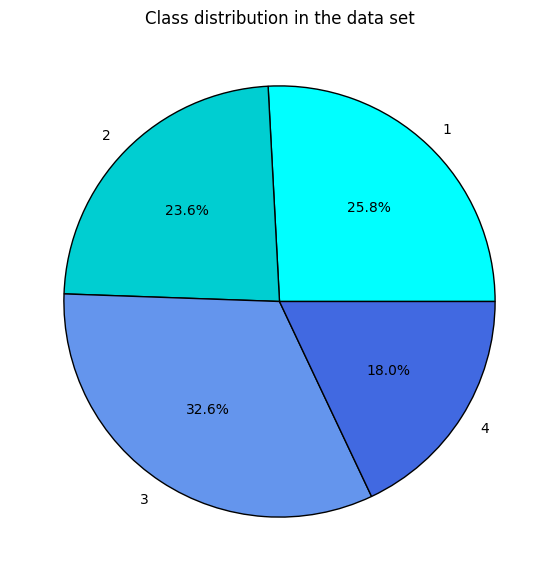

In [ ]:
PFAS_class =['1','2', '3','4']
percent = [23, 21, 29, 16]
colors=['cyan', 'darkturquoise','cornflowerblue','royalblue']
plt.figure(figsize =(10, 7))
plt.pie(percent, labels = PFAS_class,  colors = colors, autopct='%1.1f%%',  wedgeprops={"linewidth": 1, "edgecolor": "black"})

plt.title('Class distribution in the data set')
plt.show()

In [ ]:
to_scale = data.iloc[:,8:21]
scaler = StandardScaler()
df_scaler = scaler.fit_transform(to_scale)
df_scaler = pd.DataFrame(df_scaler, columns=to_scale.columns)
df_scaler

,LogP,TPSA,SASA,EHOMO,ELUMO,Gap,Hardness,Softness,Mu,Omega,HF_Energy,RMSD,ZeroPoint
0,-0.671116,0.987421,-0.568599,0.455201,-0.147054,-0.281851,-0.282003,0.248955,-0.631872,-0.041293,0.353504,-0.4022,-0.460430
1,-0.671116,0.987421,-0.568599,0.455201,-0.147054,-0.281851,-0.282003,0.248955,-0.631872,-0.041293,0.353504,-0.4022,-0.460430
2,-0.671116,0.987421,-0.568599,0.455201,-0.147054,-0.281851,-0.282003,0.248955,-0.631872,-0.041293,0.353504,-0.4022,-0.460430
3,-0.671116,0.987421,-0.568599,0.455201,-0.147054,-0.281851,-0.282003,0.248955,-0.631872,-0.041293,0.353504,-0.4022,-0.460430
4,-0.671116,0.987421,-0.568599,0.455201,-0.147054,-0.281851,-0.282003,0.248955,-0.631872,-0.041293,0.353504,-0.4022,-0.460430
...,...,...,...,...,...,...,...,...,...,...,...,...,...
74,1.733962,-1.012739,1.494943,0.833344,-0.891547,-0.872162,-0.872135,0.880357,0.825571,0.914302,-0.929003,-0.4022,1.571712
75,1.733962,-1.012739,1.494943,0.833344,-0.891547,-0.872162,-0.872135,0.880357,0.825571,0.914302,-0.929003,-0.4022,1.571712
76,1.733962,-1.012739,1.494943,0.833344,-0.891547,-0.872162,-0.872135,0.880357,0.825571,0.914302,-0.929003,-0.4022,1.571712
77,1.733962,-1.012739,1.494943,0.833344,-0.891547,-0.872162,-0.872135,0.880357,0.825571,0.914302,-0.929003,-0.4022,1.571712


In [ ]:
his_data = data[['Sex','Species','AVERAGE_MASS','ProxTubDiam','LogP_pred', 'GlomTotSA_ProxTubTotVol_ratio']]
endpoint = data['ClassPredFull']

df = pd.concat([his_data, df_scaler, endpoint], axis=1)
df

,Sex,Species,AVERAGE_MASS,ProxTubDiam,LogP_pred,GlomTotSA_ProxTubTotVol_ratio,LogP,TPSA,SASA,EHOMO,ELUMO,Gap,Hardness,Softness,Mu,Omega,HF_Energy,RMSD,ZeroPoint,ClassPredFull
0,1,4,-0.577936,1.654466,-0.160634,1.710562,-0.671116,0.987421,-0.568599,0.455201,-0.147054,-0.281851,-0.282003,0.248955,-0.631872,-0.041293,0.353504,-0.4022,-0.460430,2
1,1,2,-0.577936,-0.552567,-0.160634,-0.320640,-0.671116,0.987421,-0.568599,0.455201,-0.147054,-0.281851,-0.282003,0.248955,-0.631872,-0.041293,0.353504,-0.4022,-0.460430,2
2,0,3,-0.577936,0.088924,-0.160634,-0.757934,-0.671116,0.987421,-0.568599,0.455201,-0.147054,-0.281851,-0.282003,0.248955,-0.631872,-0.041293,0.353504,-0.4022,-0.460430,2
3,1,2,-0.577936,-0.552567,-0.160634,-0.320640,-0.671116,0.987421,-0.568599,0.455201,-0.147054,-0.281851,-0.282003,0.248955,-0.631872,-0.041293,0.353504,-0.4022,-0.460430,2
4,1,3,-0.577936,0.088924,-0.160634,-0.757934,-0.671116,0.987421,-0.568599,0.455201,-0.147054,-0.281851,-0.282003,0.248955,-0.631872,-0.041293,0.353504,-0.4022,-0.460430,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74,0,2,1.471202,-0.552567,0.841769,-0.320640,1.733962,-1.012739,1.494943,0.833344,-0.891547,-0.872162,-0.872135,0.880357,0.825571,0.914302,-0.929003,-0.4022,1.571712,3
75,1,2,1.471202,-0.552567,0.841769,-0.320640,1.733962,-1.012739,1.494943,0.833344,-0.891547,-0.872162,-0.872135,0.880357,0.825571,0.914302,-0.929003,-0.4022,1.571712,3
76,1,2,1.471202,-0.552567,0.841769,-0.320640,1.733962,-1.012739,1.494943,0.833344,-0.891547,-0.872162,-0.872135,0.880357,0.825571,0.914302,-0.929003,-0.4022,1.571712,3
77,0,2,1.471202,-0.552567,0.841769,-0.320640,1.733962,-1.012739,1.494943,0.833344,-0.891547,-0.872162,-0.872135,0.880357,0.825571,0.914302,-0.929003,-0.4022,1.571712,3


In [ ]:
train = data.iloc[0:57,:]
X_train = train.iloc[0:57,2:-1]
X_train = pd.DataFrame(X_train)
y_train = train.iloc[:,-1]
y_train = pd.DataFrame(y_train)

test = data.iloc[57:,:]

X_test = test.iloc[:,2:-1]
y_test =test.iloc[:,-1]
y_test = pd.DataFrame(y_test)


In [ ]:
test['PREFERRED_NAME'].unique()

array(['Perfluorononanoic acid', 'Perfluorobutanoic acid',
       'Perfluorodecanoic acid'], dtype=object)

In [ ]:
test['PREFERRED_NAME'].unique()

array(['Perfluorononanoic acid', 'Perfluorobutanoic acid',
       'Perfluorodecanoic acid'], dtype=object)

In [ ]:
X_train.columns = train.columns[2:22]
X_train.head()

,Species,Sex,AVERAGE_MASS,ProxTubDiam,LogP_pred,GlomTotSA_ProxTubTotVol_ratio,LogP,TPSA,SASA,EHOMO,ELUMO,Gap,Hardness,Softness,Mu,Omega,HF_Energy,RMSD,ZeroPoint,Dipole
0,4,1,-0.577936,1.654466,-0.160634,1.710562,3.266,94.5,176.5496,-11.0481,1.0158,12.0639,6.0319,0.1658,5.0161,2.0857,-1553.3455,2.860000e-09,0.0934,2.8656
1,2,1,-0.577936,-0.552567,-0.160634,-0.320640,3.266,94.5,176.5496,-11.0481,1.0158,12.0639,6.0319,0.1658,5.0161,2.0857,-1553.3455,2.860000e-09,0.0934,2.8656
2,3,0,-0.577936,0.088924,-0.160634,-0.757934,3.266,94.5,176.5496,-11.0481,1.0158,12.0639,6.0319,0.1658,5.0161,2.0857,-1553.3455,2.860000e-09,0.0934,2.8656
3,2,1,-0.577936,-0.552567,-0.160634,-0.320640,3.266,94.5,176.5496,-11.0481,1.0158,12.0639,6.0319,0.1658,5.0161,2.0857,-1553.3455,2.860000e-09,0.0934,2.8656
4,3,1,-0.577936,0.088924,-0.160634,-0.757934,3.266,94.5,176.5496,-11.0481,1.0158,12.0639,6.0319,0.1658,5.0161,2.0857,-1553.3455,2.860000e-09,0.0934,2.8656


In [ ]:
train.columns[8:22]

Index(['LogP', 'TPSA', 'SASA', 'EHOMO', 'ELUMO', 'Gap', 'Hardness', 'Softness',
       'Mu', 'Omega', 'HF_Energy', 'RMSD', 'ZeroPoint', 'Dipole'],
      dtype='object')

In [ ]:
scale = X_train.iloc[:,6:22]
scaler = StandardScaler()
X_train_scale= scaler.fit_transform(scale)
X_train_scale = pd.DataFrame(X_train_scale, columns=scale.columns)
X_train_scale.head()

,LogP,TPSA,SASA,EHOMO,ELUMO,Gap,Hardness,Softness,Mu,Omega,HF_Energy,RMSD,ZeroPoint,Dipole
0,-0.623538,0.65192,-0.74643,0.804395,-0.501164,-0.638315,-0.63845,0.610968,-0.337685,0.310402,0.327536,-0.48901,-0.554745,-1.102437
1,-0.623538,0.65192,-0.74643,0.804395,-0.501164,-0.638315,-0.63845,0.610968,-0.337685,0.310402,0.327536,-0.48901,-0.554745,-1.102437
2,-0.623538,0.65192,-0.74643,0.804395,-0.501164,-0.638315,-0.63845,0.610968,-0.337685,0.310402,0.327536,-0.48901,-0.554745,-1.102437
3,-0.623538,0.65192,-0.74643,0.804395,-0.501164,-0.638315,-0.63845,0.610968,-0.337685,0.310402,0.327536,-0.48901,-0.554745,-1.102437
4,-0.623538,0.65192,-0.74643,0.804395,-0.501164,-0.638315,-0.63845,0.610968,-0.337685,0.310402,0.327536,-0.48901,-0.554745,-1.102437


In [ ]:
his_data = X_train[['Sex','Species','ProxTubDiam', 'GlomTotSA_ProxTubTotVol_ratio']]


X_train_ready = pd.concat([his_data, X_train_scale], axis=1)
X_train_ready.head()


,Sex,Species,ProxTubDiam,GlomTotSA_ProxTubTotVol_ratio,LogP,TPSA,SASA,EHOMO,ELUMO,Gap,Hardness,Softness,Mu,Omega,HF_Energy,RMSD,ZeroPoint,Dipole
0,1,4,1.654466,1.710562,-0.623538,0.65192,-0.74643,0.804395,-0.501164,-0.638315,-0.63845,0.610968,-0.337685,0.310402,0.327536,-0.48901,-0.554745,-1.102437
1,1,2,-0.552567,-0.320640,-0.623538,0.65192,-0.74643,0.804395,-0.501164,-0.638315,-0.63845,0.610968,-0.337685,0.310402,0.327536,-0.48901,-0.554745,-1.102437
2,0,3,0.088924,-0.757934,-0.623538,0.65192,-0.74643,0.804395,-0.501164,-0.638315,-0.63845,0.610968,-0.337685,0.310402,0.327536,-0.48901,-0.554745,-1.102437
3,1,2,-0.552567,-0.320640,-0.623538,0.65192,-0.74643,0.804395,-0.501164,-0.638315,-0.63845,0.610968,-0.337685,0.310402,0.327536,-0.48901,-0.554745,-1.102437
4,1,3,0.088924,-0.757934,-0.623538,0.65192,-0.74643,0.804395,-0.501164,-0.638315,-0.63845,0.610968,-0.337685,0.310402,0.327536,-0.48901,-0.554745,-1.102437


In [ ]:
scale = X_test.iloc[:,6:22]
scaler = StandardScaler()
X_test_scale= scaler.fit_transform(scale)
X_test_scale = pd.DataFrame(X_test_scale, columns=scale.columns)
X_test_scale.head()

,LogP,TPSA,SASA,EHOMO,ELUMO,Gap,Hardness,Softness,Mu,Omega,HF_Energy,RMSD,ZeroPoint,Dipole
0,0.585164,0.0,0.585164,-0.828029,-1.179064,0.76485,0.761914,-0.755929,0.874213,0.926641,-0.585164,-1.320854,0.583852,-0.748407
1,0.585164,0.0,0.585164,-0.828029,-1.179064,0.76485,0.761914,-0.755929,0.874213,0.926641,-0.585164,-1.320854,0.583852,-0.748407
2,0.585164,0.0,0.585164,-0.828029,-1.179064,0.76485,0.761914,-0.755929,0.874213,0.926641,-0.585164,-1.320854,0.583852,-0.748407
3,0.585164,0.0,0.585164,-0.828029,-1.179064,0.76485,0.761914,-0.755929,0.874213,0.926641,-0.585164,-1.320854,0.583852,-0.748407
4,0.585164,0.0,0.585164,-0.828029,-1.179064,0.76485,0.761914,-0.755929,0.874213,0.926641,-0.585164,-1.320854,0.583852,-0.748407


In [ ]:
his_data1 = X_test[['Sex','Species','ProxTubDiam', 'GlomTotSA_ProxTubTotVol_ratio']]


his_data1 = his_data1.reset_index(drop=True)
X_test_scale = X_test_scale.reset_index(drop=True)


X_test_ready = pd.concat([his_data1, X_test_scale], axis=1)
X_test_ready.head()

,Sex,Species,ProxTubDiam,GlomTotSA_ProxTubTotVol_ratio,LogP,TPSA,SASA,EHOMO,ELUMO,Gap,Hardness,Softness,Mu,Omega,HF_Energy,RMSD,ZeroPoint,Dipole
0,1,2,-0.552567,-0.320640,0.585164,0.0,0.585164,-0.828029,-1.179064,0.76485,0.761914,-0.755929,0.874213,0.926641,-0.585164,-1.320854,0.583852,-0.748407
1,1,4,1.654466,1.710562,0.585164,0.0,0.585164,-0.828029,-1.179064,0.76485,0.761914,-0.755929,0.874213,0.926641,-0.585164,-1.320854,0.583852,-0.748407
2,0,4,1.654466,1.710562,0.585164,0.0,0.585164,-0.828029,-1.179064,0.76485,0.761914,-0.755929,0.874213,0.926641,-0.585164,-1.320854,0.583852,-0.748407
3,1,2,-0.552567,-0.320640,0.585164,0.0,0.585164,-0.828029,-1.179064,0.76485,0.761914,-0.755929,0.874213,0.926641,-0.585164,-1.320854,0.583852,-0.748407
4,0,1,-1.116389,-0.959841,0.585164,0.0,0.585164,-0.828029,-1.179064,0.76485,0.761914,-0.755929,0.874213,0.926641,-0.585164,-1.320854,0.583852,-0.748407


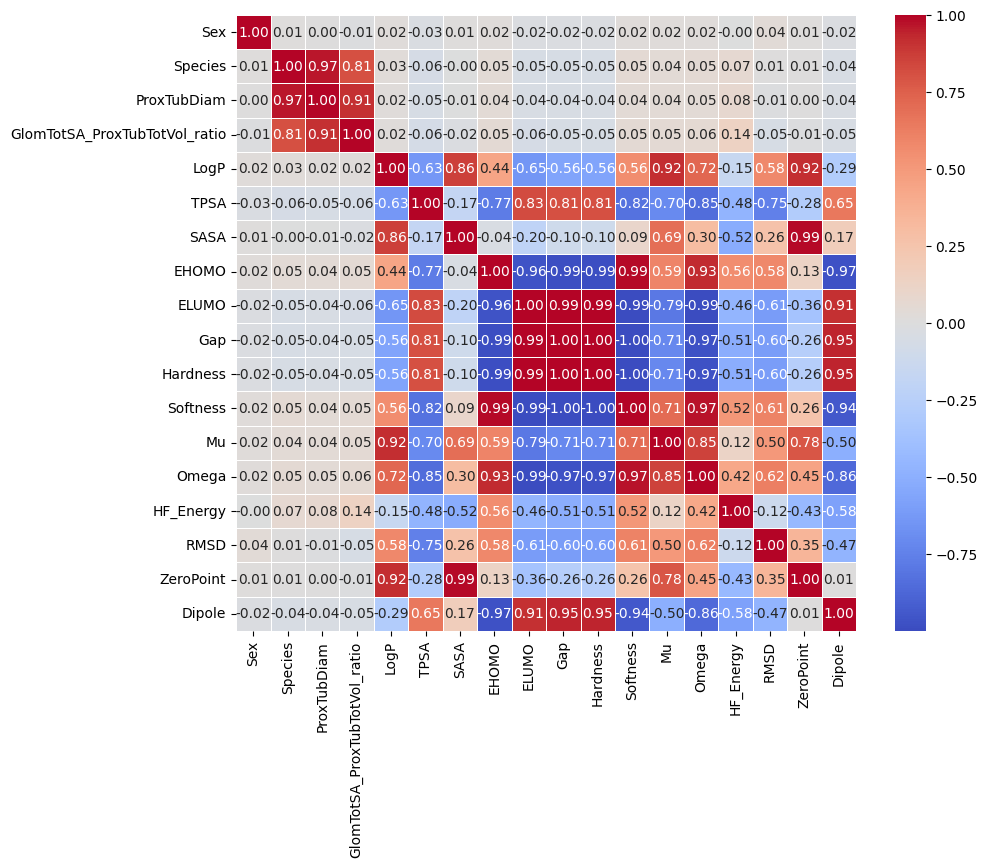

In [ ]:
corr_matrix = X_train_ready.corr()
plt.figure(figsize=(10, 8)) 
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.show()

In [ ]:
matrix = pd.DataFrame(np.triu(corr_matrix, k=1),columns=corr_matrix.columns, index=corr_matrix.index)

to_drop = [column for column in matrix.columns if any(matrix[column] > 0.90)]
to_drop

X_train_ready.drop(to_drop, axis=1, inplace=True)
X_train_ready.head()


,Sex,Species,LogP,TPSA,SASA,EHOMO,ELUMO,HF_Energy,RMSD
0,1,4,-0.623538,0.65192,-0.74643,0.804395,-0.501164,0.327536,-0.48901
1,1,2,-0.623538,0.65192,-0.74643,0.804395,-0.501164,0.327536,-0.48901
2,0,3,-0.623538,0.65192,-0.74643,0.804395,-0.501164,0.327536,-0.48901
3,1,2,-0.623538,0.65192,-0.74643,0.804395,-0.501164,0.327536,-0.48901
4,1,3,-0.623538,0.65192,-0.74643,0.804395,-0.501164,0.327536,-0.48901


In [ ]:
selected_columns = ['Sex', 'Species','LogP','SASA', 'Gap', 'HF_Energy']

X_test = X_test[selected_columns]
X_train = X_train[selected_columns]

X_test = X_test[selected_columns]
X_train = X_train[selected_columns]

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn import metrics
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)


y_pred_knn = knn.predict(X_test)
y_pred_train_knn = knn.predict(X_train)

c:\Users\Julia\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\neighbors\_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


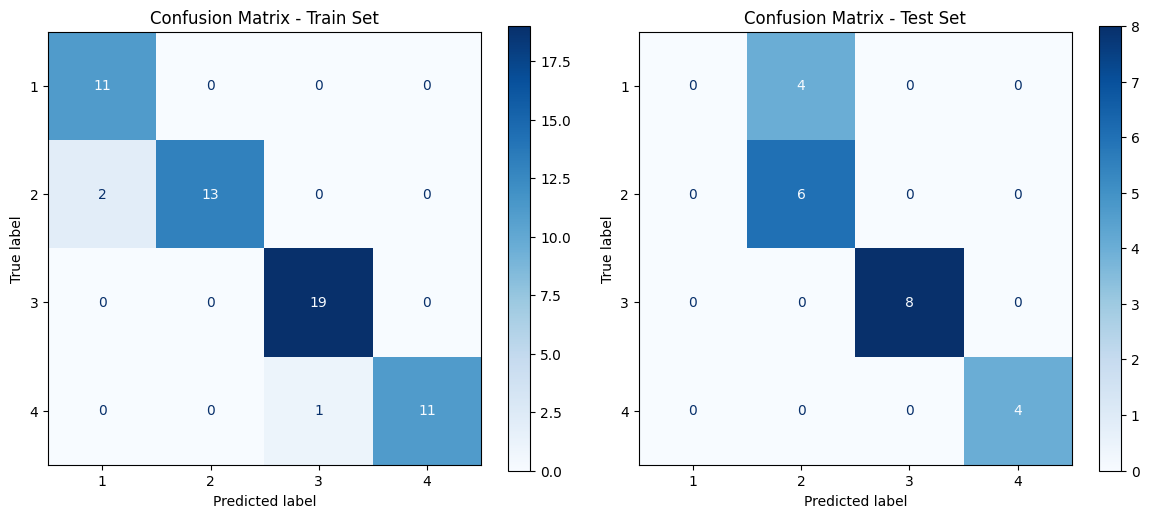

In [ ]:
conf_matrix_test = metrics.confusion_matrix(y_test, y_pred_knn)
conf_matrix_train = metrics.confusion_matrix(y_train, y_pred_train_knn)

labels = ['1', '2', '3', '4']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))


metrics.ConfusionMatrixDisplay(
    confusion_matrix=conf_matrix_train,
    display_labels=labels
).plot(ax=axes[0], cmap=plt.cm.Blues)
axes[0].set_title('Confusion Matrix - Train Set')

metrics.ConfusionMatrixDisplay(
    confusion_matrix=conf_matrix_test,
    display_labels=labels
).plot(ax=axes[1], cmap=plt.cm.Blues)
axes[1].set_title('Confusion Matrix - Test Set')

plt.tight_layout()
plt.show()

In [ ]:
print(y_test.value_counts())

ClassPredFull
3                8
2                6
1                4
4                4
Name: count, dtype: int64


In [ ]:
print(y_train.value_counts())

ClassPredFull
3                19
2                15
4                12
1                11
Name: count, dtype: int64


In [ ]:
y_pred_knn

array([3, 4, 4, 3, 3, 2, 2, 3, 2, 2, 2, 2, 2, 2, 2, 2, 4, 3, 3, 3, 3, 4],
      dtype=int64)

In [ ]:
print("Accuracy_v", metrics.accuracy_score(y_test, y_pred_knn))
print("Accuracy_t", metrics.accuracy_score(y_train, y_pred_train_knn))


print("Precision_v", metrics.precision_score(y_test, y_pred_knn, average='weighted'))
print("Precision_t", metrics.precision_score(y_train, y_pred_train_knn, average='weighted'))


print("Recall_v", metrics.recall_score(y_test, y_pred_knn, average='weighted'))
print("Recall_t", metrics.recall_score(y_train, y_pred_train_knn, average='weighted'))


print("F1_score_v", metrics.f1_score(y_test, y_pred_knn, average='weighted'))
print("F1_score_t", metrics.f1_score(y_train, y_pred_train_knn, average='weighted'))

Accuracy_v 0.8181818181818182
Accuracy_t 0.9473684210526315
Precision_v 0.7090909090909091
Precision_t 0.9536437246963562
Recall_v 0.8181818181818182
Recall_t 0.9473684210526315
F1_score_v 0.75
F1_score_t 0.9474208095489559


c:\Users\Julia\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
from xgboost import XGBClassifier

y_train = y_train - y_train.min()
xgb = XGBClassifier(
    n_estimators=10,        
    learning_rate=0.1,       
    max_depth=3,            
   
)
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)
y_pred_train_xgb = xgb.predict(X_train)


y_train = y_train + 1
y_pred_xgb = y_pred_xgb + 1
y_pred_train_xgb = y_pred_train_xgb +1

In [ ]:
print("Accuracy_v", metrics.accuracy_score(y_test, y_pred_xgb))
print("Accuracy_t", metrics.accuracy_score(y_train, y_pred_train_xgb))


print("Precision_v", metrics.precision_score(y_test, y_pred_xgb, average='weighted'))
print("Precision_t", metrics.precision_score(y_train, y_pred_train_xgb, average='weighted'))


print("Recall_v", metrics.recall_score(y_test, y_pred_xgb, average='weighted'))
print("Recall_t", metrics.recall_score(y_train, y_pred_train_xgb, average='weighted'))


print("F1_score_v", metrics.f1_score(y_test, y_pred_xgb, average='weighted'))
print("F1_score_t", metrics.f1_score(y_train, y_pred_train_xgb, average='weighted'))

Accuracy_v 0.9090909090909091
Accuracy_t 0.8947368421052632
Precision_v 0.9272727272727272
Precision_t 0.8989139515455304
Recall_v 0.9090909090909091
Recall_t 0.8947368421052632
F1_score_v 0.9050505050505051
F1_score_t 0.895438308414715


In [ ]:
combined_preds = pd.concat([
    pd.Series(y_pred_train_xgb),
    pd.Series(y_pred_xgb)
], ignore_index=True)


df = pd.DataFrame({'Predictions': combined_preds})

df.to_excel('predictions.xlsx', index=False)

In [ ]:
y_pred_train_xgb
y_pred_xgb

array([3, 4, 4, 3, 3, 3, 3, 3, 2, 2, 2, 2, 1, 1, 1, 1, 4, 3, 3, 3, 3, 4],
      dtype=int64)

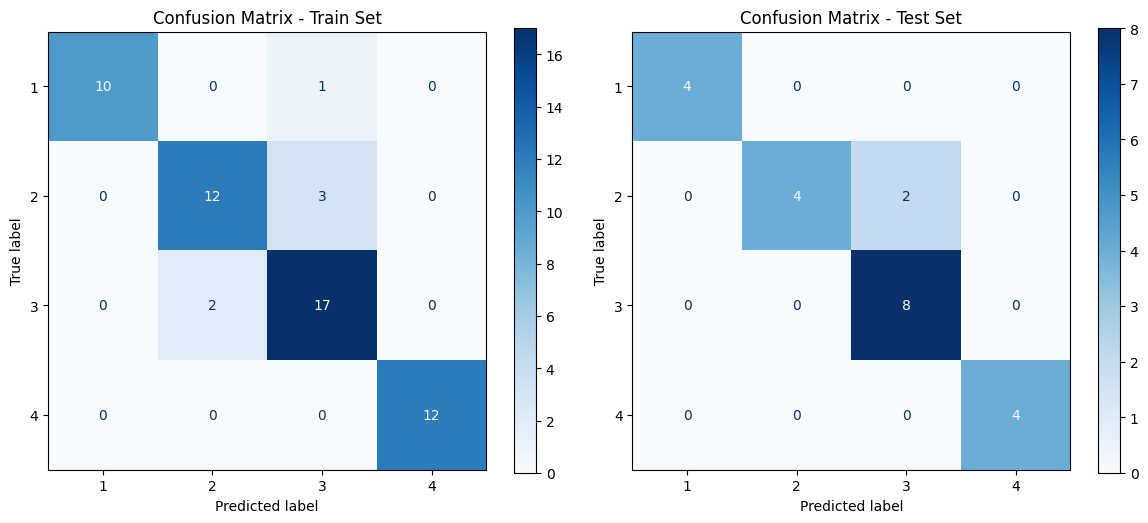

In [ ]:
conf_matrix_test = metrics.confusion_matrix(y_test, y_pred_xgb)
conf_matrix_train = metrics.confusion_matrix(y_train, y_pred_train_xgb)

labels = ['1', '2', '3', '4']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))


metrics.ConfusionMatrixDisplay(
    confusion_matrix=conf_matrix_train,
    display_labels=labels
).plot(ax=axes[0], cmap=plt.cm.Blues)
axes[0].set_title('Confusion Matrix - Train Set')

metrics.ConfusionMatrixDisplay(
    confusion_matrix=conf_matrix_test,
    display_labels=labels
).plot(ax=axes[1], cmap=plt.cm.Blues)
axes[1].set_title('Confusion Matrix - Test Set')

plt.tight_layout()
plt.show()

In [ ]:
from sklearn import tree

dt = tree.DecisionTreeClassifier(
    max_depth=3,             
    min_samples_leaf=10,   
    min_samples_split=3,                
    random_state=42)
dt = dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

y_pred_train_dt = dt.predict(X_train)

In [ ]:
print("Accuracy_v", metrics.accuracy_score(y_test, y_pred_dt))
print("Accuracy_t", metrics.accuracy_score(y_train, y_pred_train_dt))


print("Precision_v", metrics.precision_score(y_test, y_pred_dt, average='weighted'))
print("Precision_t", metrics.precision_score(y_train, y_pred_train_dt, average='weighted'))


print("Recall_v", metrics.recall_score(y_test, y_pred_dt, average='weighted'))
print("Recall_t", metrics.recall_score(y_train, y_pred_train_dt, average='weighted'))


print("F1_score_v", metrics.f1_score(y_test, y_pred_dt, average='weighted'))
print("F1_score_t", metrics.f1_score(y_train, y_pred_train_dt, average='weighted'))

Accuracy_v 0.9090909090909091
Accuracy_t 0.7017543859649122
Precision_v 0.9272727272727272
Precision_t 0.6997113510271405
Recall_v 0.9090909090909091
Recall_t 0.7017543859649122
F1_score_v 0.9050505050505051
F1_score_t 0.6899390618688864


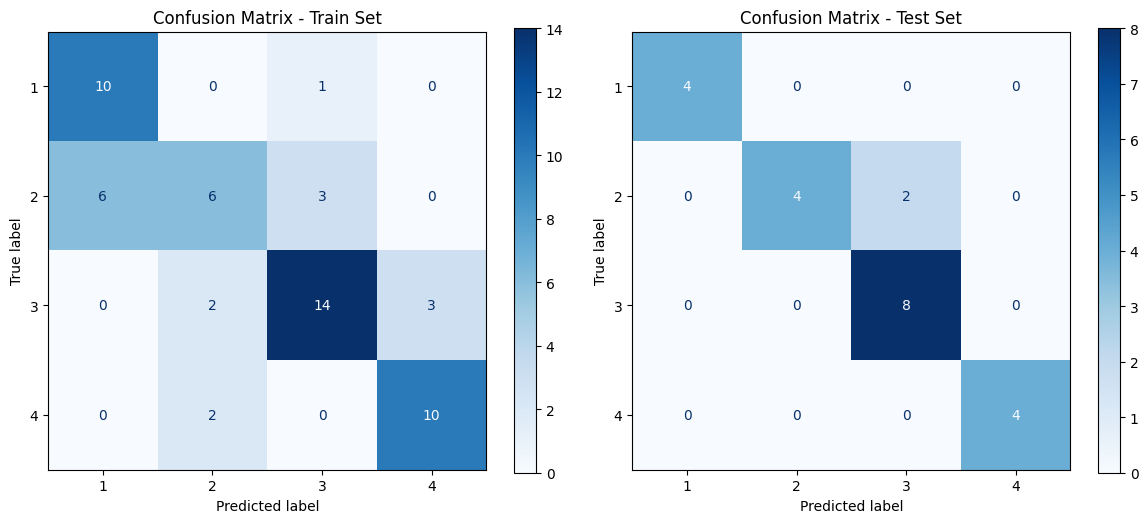

In [ ]:
conf_matrix_test = metrics.confusion_matrix(y_test, y_pred_dt)
conf_matrix_train = metrics.confusion_matrix(y_train, y_pred_train_dt)


labels = ['1', '2', '3', '4']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))


metrics.ConfusionMatrixDisplay(
    confusion_matrix=conf_matrix_train,
    display_labels=labels
).plot(ax=axes[0], cmap=plt.cm.Blues)
axes[0].set_title('Confusion Matrix - Train Set')

metrics.ConfusionMatrixDisplay(
    confusion_matrix=conf_matrix_test,
    display_labels=labels
).plot(ax=axes[1], cmap=plt.cm.Blues)
axes[1].set_title('Confusion Matrix - Test Set')

plt.tight_layout()
plt.show()

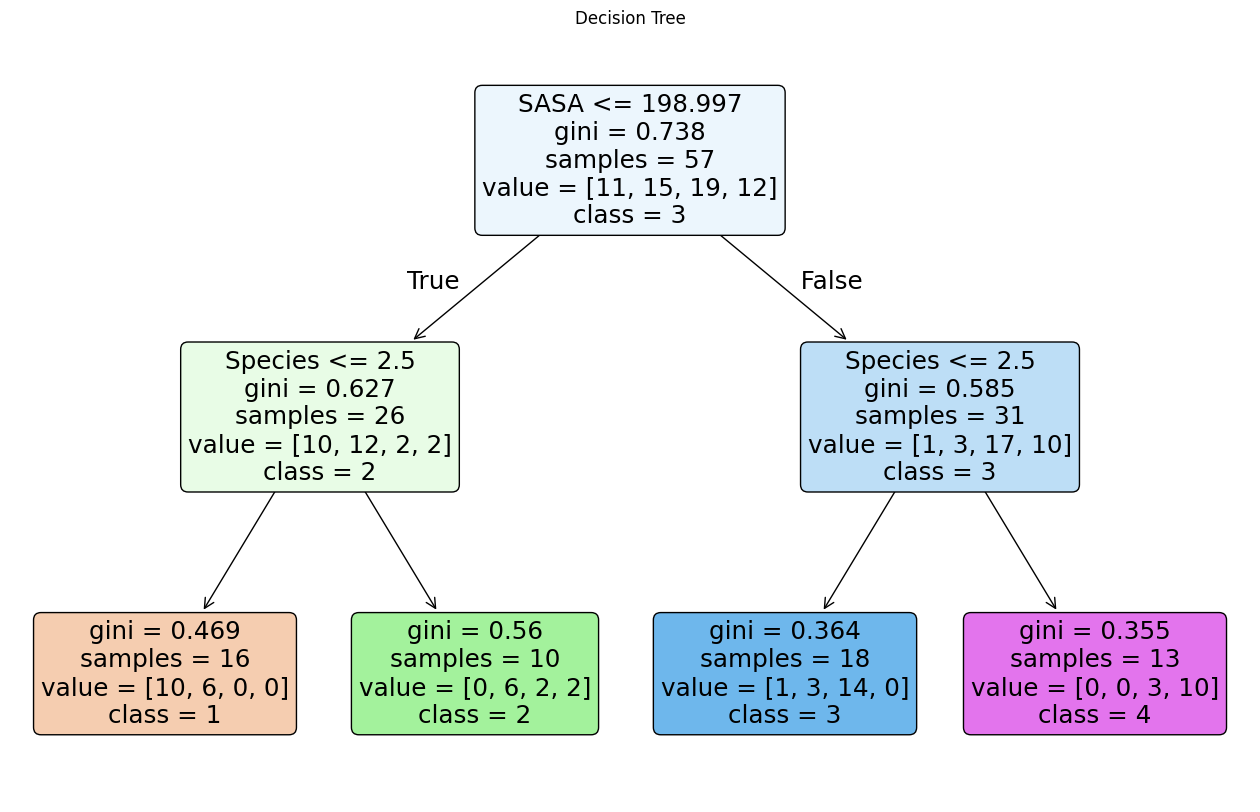

In [ ]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(16, 10))
plot_tree(
    dt,
    feature_names=X_train.columns, 
    class_names= ['1', '2', '3', '4'],
    filled=True,
    rounded=True
)
plt.title("Decision Tree")
plt.show()

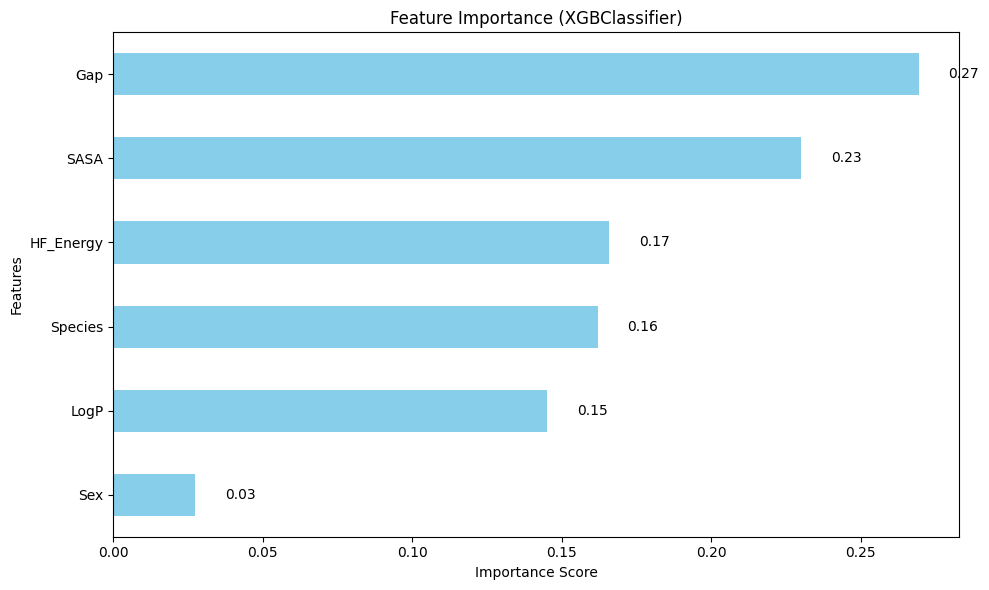

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Oblicz i zaokrąglij ważność cech
importances = pd.Series(xgb.feature_importances_, index=X_train.columns)
importances = importances.sort_values(ascending=True)  # rosnąco dla czytelności wykresu poziomego

# Wykres poziomy
plt.figure(figsize=(10, 6))
ax = importances.plot(kind='barh', color='skyblue')

# Dodajemy wartości nad słupkami z 2 miejscami po przecinku
for i, v in enumerate(importances):
    ax.text(v + 0.01, i, f'{v:.2f}', color='black', va='center')

plt.title('Feature Importance (XGBClassifier)')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()